<a href="https://colab.research.google.com/github/yawarabbasmalik/Airlines-Arrival-Delay-Analysis/blob/main/Airlines_Arrival_Delay_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

In [ ]:
# Load the data
df = pd.read_csv('/content/UK_NATIONAL_AIRLINES_DATA_CW1 (S) (1).csv', encoding='ISO-8859-1')

In [ ]:
df.head()

,Ref,id,Gender,Satisfied,Age,Age Band,Type of Travel,Class,Flight Distance,Destination,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,0,70172,Male,Y,13,Under 18,Personal Travel,Eco Plus,4760,India,...,5,5,4,3,4,4,5,5,25,18.0
1,1,5047,Male,N,25,25 to 34,Business travel,Business,235,Republic of Ireland,...,1,1,1,5,3,1,4,1,1,6.0
2,2,110028,Female,Y,26,25 to 34,Business travel,Business,4760,India,...,5,5,4,3,4,4,4,5,0,0.0
3,3,24026,Female,Y,25,25 to 34,Business travel,Business,560,Norway,...,2,2,2,5,3,1,4,2,11,9.0
4,4,119299,Male,Y,61,55 to 64,Business travel,Business,4760,India,...,5,3,3,4,4,3,3,3,0,0.0


In [ ]:
# Confirming the Null Values in the Entire dataset
df.isna().sum()

,0
Ref,0
id,0
Gender,0
Satisfied,0
Age,0
Age Band,0
Type of Travel,0
Class,0
Flight Distance,0
Destination,0


There exists 310 Null values only in one attribute i.e., "Arrival Delay in Minutes"

In [ ]:
# Confirming the Duplicate Values in the Entire dataset
df.duplicated().sum()

0

In [ ]:
# Get DataFrame shape
shape = df.shape
print('DataFrame Shape :', shape)
print('Number of rows :', shape[0])
print('Number of columns :', shape[1])

DataFrame Shape : (103904, 27)
Number of rows : 103904
Number of columns : 27


In [ ]:
# Data type of all attributes
df.dtypes

,0
Ref,int64
id,int64
Gender,object
Satisfied,object
Age,int64
Age Band,object
Type of Travel,object
Class,object
Flight Distance,int64
Destination,object


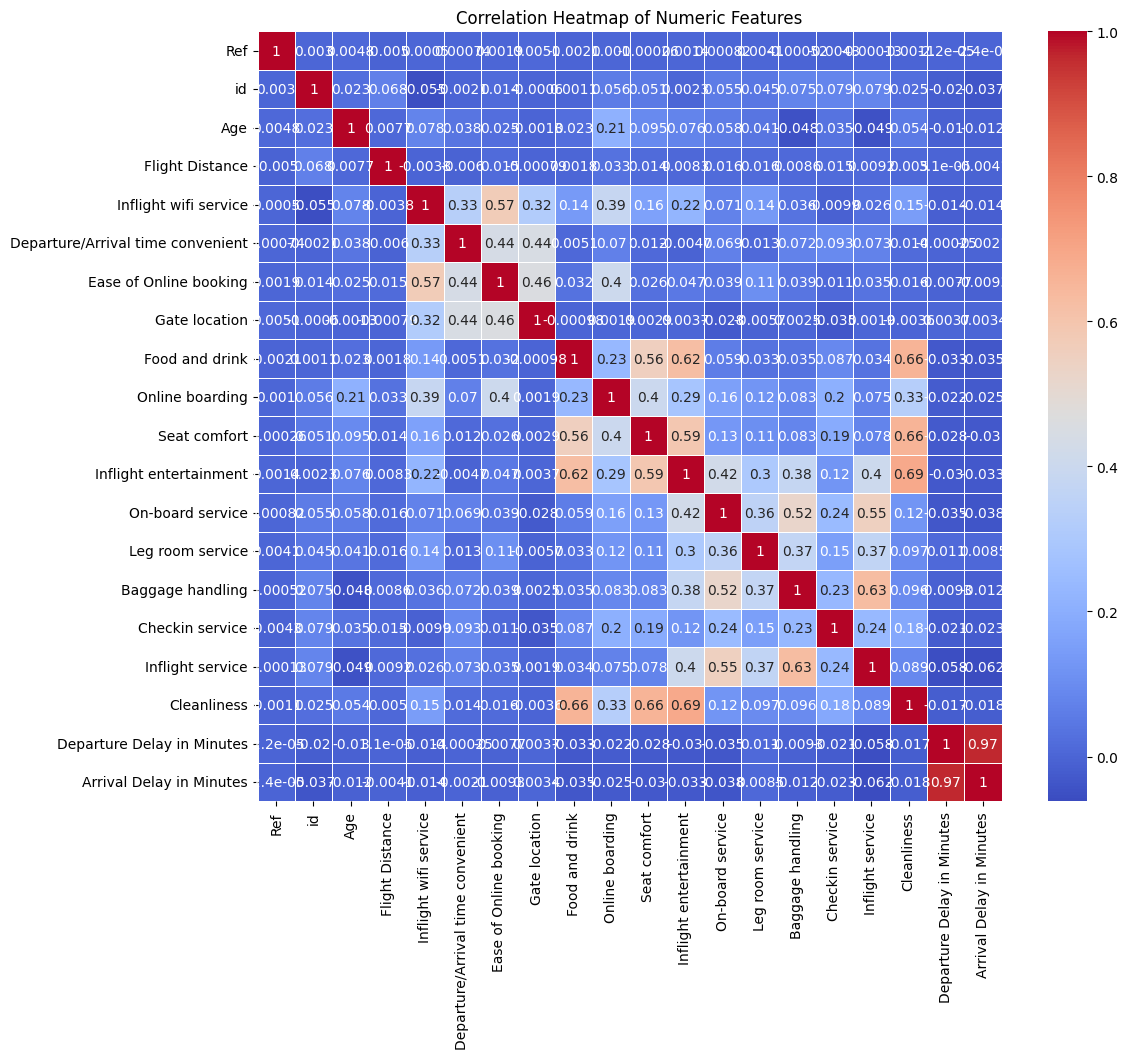

In [ ]:
# Correlation heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(12, 10))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

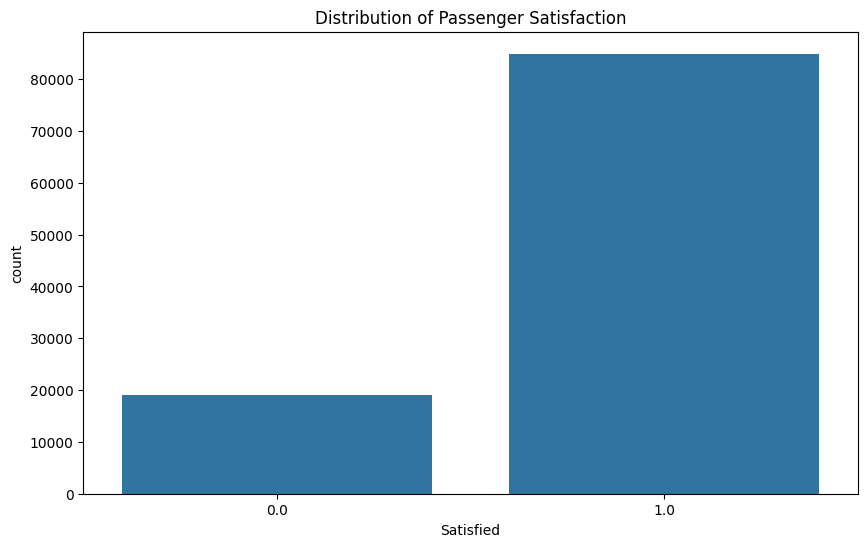

In [ ]:
# Exploratory Data Analysis
plt.figure(figsize=(10, 6))
sns.countplot(x='Satisfied', data=df)
plt.title('Distribution of Passenger Satisfaction')
plt.show()

In [ ]:
# Creating a copy of the dataframe for encoding and normalization
df_encoded = df.copy()

# Initializing Label Encoder
le = LabelEncoder()

# Applying Label Encoding to categorical columns
categorical_columns = df_encoded.select_dtypes(include=['object']).columns
for column in categorical_columns:
    df_encoded[column] = le.fit_transform(df_encoded[column])

# Applying Min-Max Normalization
scaler = MinMaxScaler()
df_normalized = pd.DataFrame(scaler.fit_transform(df_encoded), columns=df_encoded.columns)

# Displaying the first few rows of the normalized dataframe
df = df_normalized
df.head()

,Ref,id,Gender,Satisfied,Age,Age Band,Type of Travel,Class,Flight Distance,Destination,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,0.000000,0.540280,1.0,1.0,0.076923,1.000000,1.0,1.0,0.793164,0.316327,...,1.0,1.0,0.8,0.6,0.8,0.8,1.0,1.0,0.015704,0.011364
1,0.000010,0.038852,1.0,0.0,0.230769,0.166667,0.0,0.0,0.000000,0.683673,...,0.2,0.2,0.2,1.0,0.6,0.2,0.8,0.2,0.000628,0.003788
2,0.000019,0.847150,0.0,1.0,0.243590,0.166667,0.0,0.0,0.793164,0.316327,...,1.0,1.0,0.8,0.6,0.8,0.8,0.8,1.0,0.000000,0.000000
3,0.000029,0.184980,0.0,1.0,0.230769,0.166667,0.0,0.0,0.056968,0.612245,...,0.4,0.4,0.4,1.0,0.6,0.2,0.8,0.4,0.006910,0.005682
4,0.000038,0.918532,1.0,1.0,0.692308,0.666667,0.0,0.0,0.793164,0.316327,...,1.0,0.6,0.6,0.8,0.8,0.6,0.6,0.6,0.000000,0.000000


In [ ]:
# Prepare features and target
X = df.drop(['Satisfied', 'Ref', 'id', 'Departure Delay in Minutes', 'Arrival Delay in Minutes'], axis=1)
y = df['Satisfied']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Create pipelines with imputation, scaling, and model fitting
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])

lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=42))
])


In [ ]:
# Fit and predict using Random Forest pipeline
rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

print("Random Forest Results:")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, rf_pred))

print("*****************************************************")

# Fit and predict using Logistic Regression pipeline
lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)

print("\nLogistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, lr_pred))


Random Forest Results:
Accuracy: 0.9901
Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.96      0.97      3775
         1.0       0.99      1.00      0.99     17006

    accuracy                           0.99     20781
   macro avg       0.99      0.98      0.98     20781
weighted avg       0.99      0.99      0.99     20781

*****************************************************

Logistic Regression Results:
Accuracy: 0.9021
Classification Report:
              precision    recall  f1-score   support

         0.0       0.76      0.68      0.72      3775
         1.0       0.93      0.95      0.94     17006

    accuracy                           0.90     20781
   macro avg       0.84      0.81      0.83     20781
weighted avg       0.90      0.90      0.90     20781



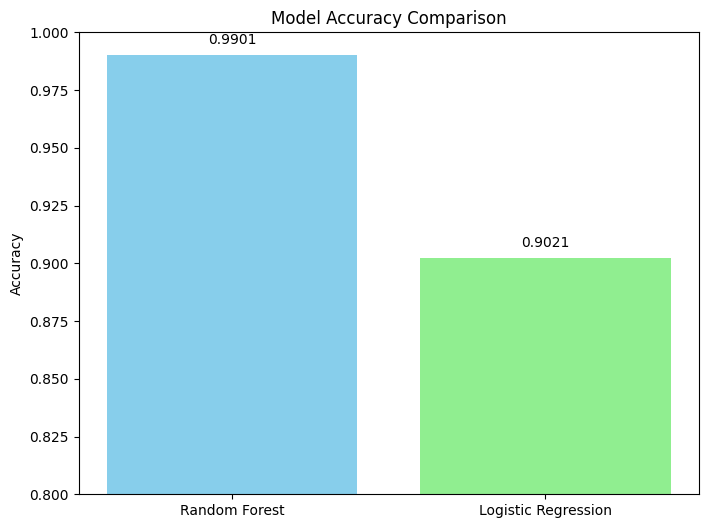

In [ ]:
# Data for visualization
models = ['Random Forest', 'Logistic Regression']
accuracies = [0.9901, 0.9021]

# Create a bar chart
plt.figure(figsize=(8, 6))
plt.bar(models, accuracies, color=['skyblue', 'lightgreen'])
plt.ylim(0.8, 1.0)  # Set y-axis limits for better visualization
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.text(0, accuracies[0] + 0.005, f'{accuracies[0]:.4f}', ha='center')
plt.text(1, accuracies[1] + 0.005, f'{accuracies[1]:.4f}', ha='center')

# Show the plot
plt.show()


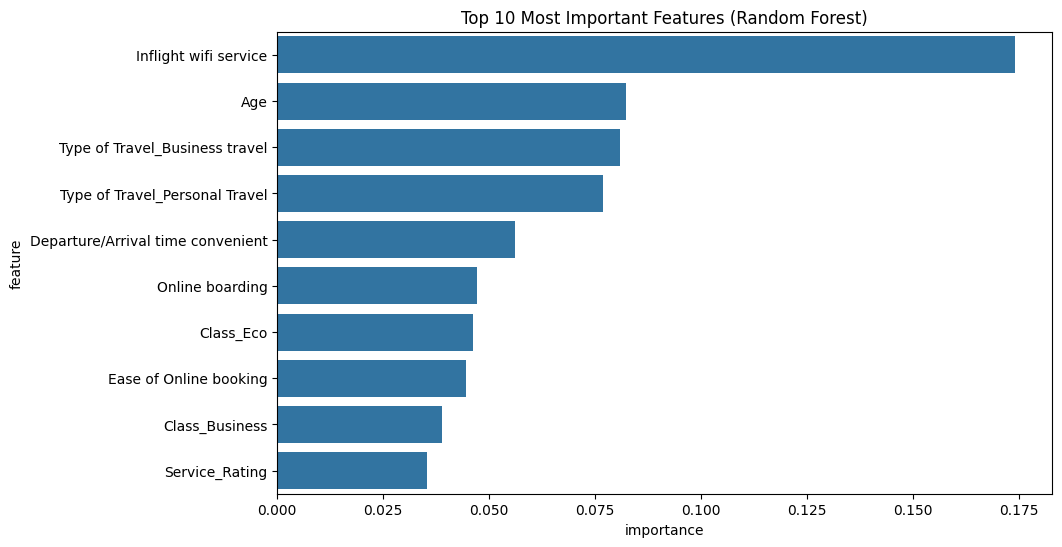

In [ ]:
# Feature Importance for Random Forest
rf_model = rf_pipeline.named_steps['rf']
feature_importance = pd.DataFrame({'feature': X.columns, 'importance': rf_model.feature_importances_})
feature_importance = feature_importance.sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Top 10 Most Important Features (Random Forest)')
plt.show()

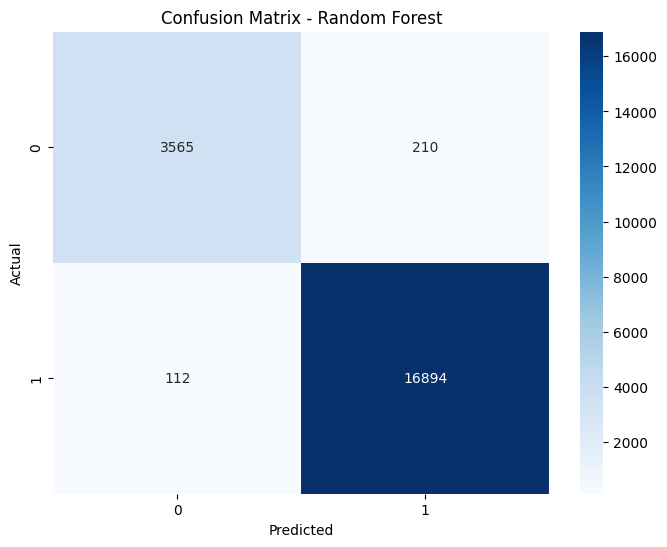

In [ ]:
# Confusion Matrix for Random Forest
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


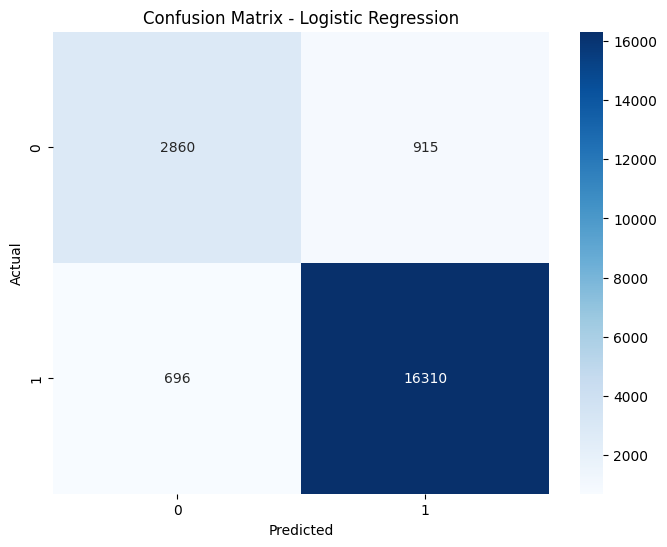

In [ ]:
# Confusion Matrix for Logistic Regression
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
